In [1]:
import numpy as np 
import os
import sys
# from osgeo import gdal, ogr, osr
import matplotlib.pyplot as plt
import seaborn as sns
import xarray as xr
import rioxarray as rxa
sns.set_theme()

from shapely import box
import geopandas as gpd

# ====== import my own functions =========
import sys
import os
scripts_dir = (os.path.dirname(os.getcwd()) + '/scripts/')
sys.path.append(scripts_dir)

from layers import assemble_data
from validation import validate_date_pairs

/bsuhome/julialober/miniforge3/envs/coherence/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Data assembly 

Start by identifying the location of the data (there are two inputs required) and the location of the shapefile for the area of interest. 

In [2]:
data_dir = '/bsuhome/julialober/scratch/coherence_data/' # on Borah 
# data_dir = '../data/'# on local machine 

# mcs_aoi = gpd.read_file(data_dir + 'mores_creek.shp')
sample_fp = data_dir + 'uavsar_cohs/mcs/05208/mcs_lowman_05208_200131_200213_coh.nc'
sample = xr.open_dataset(sample_fp)
# sample
mcs_aoi = box(*sample.rio.bounds())
# print(mcs_aoi)

getfattr: /bsuhome/julialober/scratch/coherence_data/uavsar_cohs/mcs/05208/mcs_lowman_05208_200131_200213_coh.nc: Operation not supported


I just hard coded the dates for the flights that cover MCS from flight path 05208. These need to match the dates in the filenames of the coherence files. 

In [3]:
mcs_lowman_05208_dates = ['200131_200213',
 '200131_200220',
 '200131_200311',
 '200131_210203',
 '200131_210210',
 '200131_210303',
 '200131_210310',
 '200131_210316',
 '200131_210322',
 '200213_200220',
 '200213_200311',
 '200213_210203',
 '200213_210210',
 '200213_210303',
 '200213_210310',
 '200213_210316',
 '200213_210322',
 '200220_200311',
 '200220_210203',
 '200220_210210',
 '200220_210303',
 '200220_210310',
 '200220_210316',
 '200220_210322',
 '200311_210203',
 '200311_210210',
 '200311_210303',
 '200311_210310',
 '200311_210316',
 '200311_210322',
 '210203_210210',
 '210203_210303',
 '210203_210310',
 '210203_210316',
 '210203_210322',
 '210210_210303',
 '210210_210310',
 '210210_210316',
 '210210_210322',
 '210303_210310',
 '210303_210316',
 '210303_210322',
 '210310_210316',
 '210310_210322',
 '210316_210322']

split_dates = [(part[0], part[1]) for part in [d.split('_') for d in mcs_lowman_05208_dates]]
unique_dates = set([date for pair in split_dates for date in pair])
nearest_pairs = np.array(list(zip(sorted(unique_dates), sorted(unique_dates)[1:])))
nearest_pairs = [pair for pair in nearest_pairs if pair[0][:2] == pair[1][:2]]
nearest_dates = [(f"{pair[0]}_{pair[1]}") for pair in nearest_pairs]


# go from YYMMDD to YYYYMMDD
split_dates = [(f"20{date[0]}", f"20{date[1]}") for date in split_dates]

In [4]:
# clean up multi-year dates 
split_dates_sameyr = [pair for pair in split_dates if pair[0][:4] == pair[1][:4]]
split_dates_sameyr 

[('20200131', '20200213'),
 ('20200131', '20200220'),
 ('20200131', '20200311'),
 ('20200213', '20200220'),
 ('20200213', '20200311'),
 ('20200220', '20200311'),
 ('20210203', '20210210'),
 ('20210203', '20210303'),
 ('20210203', '20210310'),
 ('20210203', '20210316'),
 ('20210203', '20210322'),
 ('20210210', '20210303'),
 ('20210210', '20210310'),
 ('20210210', '20210316'),
 ('20210210', '20210322'),
 ('20210303', '20210310'),
 ('20210303', '20210316'),
 ('20210303', '20210322'),
 ('20210310', '20210316'),
 ('20210310', '20210322'),
 ('20210316', '20210322')]

In [5]:
# aoi = box(*mcs_aoi.total_bounds) # using the total bounds to get some buffer 
# test_dates = [("20200101", "20200113"), 
#          ("20200101", "20200129"),
#          ("20200113", "20200129"),
#          ("20210202", "20210214")]
dates_val = validate_date_pairs(split_dates_sameyr)
fp_out = data_dir + 'stacks/mores_creek'
coh_dir = data_dir + 'uavsar_cohs/mcs'
inc_dir = data_dir + 'inc_angle'
sc_dir = data_dir + 'NSIDC-0768'

This function requires two things be downloaded and ready: 
1. The Snow Climatology from NSIDC 

    filename: `SnowClass_NA_300m_10.0arcsec_2021_v01.0.nc`

2. Geocoded coherence files

    filename: `[...]_YYMMDD_YYMMDD_[...].?`

In [6]:
data = assemble_data(mcs_aoi,
                    dates_val,
                    ['05208'],
                    fp_out,
                    fp_coh=coh_dir,
                    fp_inc=inc_dir,
                    fp_snowclimate=sc_dir,
                    overwrite = True)
data

getfattr: /bsuhome/julialober/scratch/coherence_data/uavsar_cohs/mcs/05208/mcs_lowman_05208_200131_200213_coh.nc: Operation not supported
getfattr: /bsuhome/julialober/scratch/coherence_data/uavsar_cohs/mcs/05208/mcs_lowman_05208_200131_200220_coh.nc: Operation not supported
getfattr: /bsuhome/julialober/scratch/coherence_data/uavsar_cohs/mcs/05208/mcs_lowman_05208_200131_200311_coh.nc: Operation not supported
getfattr: /bsuhome/julialober/scratch/coherence_data/uavsar_cohs/mcs/05208/mcs_lowman_05208_200213_200220_coh.nc: Operation not supported
getfattr: /bsuhome/julialober/scratch/coherence_data/uavsar_cohs/mcs/05208/mcs_lowman_05208_200213_200311_coh.nc: Operation not supported
getfattr: /bsuhome/julialober/scratch/coherence_data/uavsar_cohs/mcs/05208/mcs_lowman_05208_200220_200311_coh.nc: Operation not supported
getfattr: /bsuhome/julialober/scratch/coherence_data/uavsar_cohs/mcs/05208/mcs_lowman_05208_210203_210210_coh.nc: Operation not supported
getfattr: /bsuhome/julialober/scra

Loaded coherence for flights ['05208'] in 1.283 seconds.
Loaded incidence angles for flights ['05208'] in 0.155 seconds.
Got DEM in 4.308 seconds.
Got topo layers: ['slope', 'aspect', 'curve'] in 0.739 seconds.


/bsuhome/julialober/miniforge3/envs/coherence/lib/python3.13/site-packages/pygeoutils/pygeoutils.py:300: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds = xr.merge(
getfattr: /bsuhome/julialober/scratch/coherence_data/NSIDC-0768/SnowClass_NA_300m_10.0arcsec_2021_v01.0.nc: Operation not supported


Got NLCD ['cover_2019', 'canopy_2019'] in 1.084 seconds.
Got snow climatology: ['snow_class'] in 27.868 seconds.
Got AORC: ['mean_temp', 'max_temp', 'total_posdeg', 'temp_diff', 'temp_diff_acq', 'freeze_thaw_cycles', 'diurnal_temp_range', 'total_precip', 'total_rain', 'total_snow', 'acq_day_precip', 'hours_blowing_snow', 'mean_wind', 'max_wind'] in 44.906 seconds.


QUEUEING TASKS | : 100%|██████████| 4/4 [00:00<00:00, 1319.27it/s]
PROCESSING TASKS | : 100%|██████████| 4/4 [00:02<00:00,  1.62it/s]
COLLECTING RESULTS | : 100%|██████████| 4/4 [00:00<00:00, 68200.07it/s]


Got SWE layers: ['swe_accum', 'swe_ablate', 'density_change'] in 35.927 seconds.


/bsuhome/julialober/miniforge3/envs/coherence/lib/python3.13/site-packages/zarr/core/dtype/npy/string.py:249: UnstableSpecificationWarning: The data type (FixedLengthUTF32(length=13, endianness='little')) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without warning in a future version of Zarr Python. Arrays stored with this data type may be unreadable by other Zarr libraries. Use this data type at your own risk! Check https://github.com/zarr-developers/zarr-extensions/tree/main/data-types for the status of data type specifications for Zarr V3.
  v3_unstable_dtype_warning(self)
/bsuhome/julialober/miniforge3/envs/coherence/lib/python3.13/site-packages/zarr/core/dtype/npy/string.py:249: UnstableSpecificationWarning: The data type (FixedLengthUTF32(length=5, endianness='little')) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without warning

<xarray.Dataset> Size: 144MB
Dimensions:             (flight_id: 1, pair: 21, y: 202, x: 262)
Coordinates:
    band                int64 8B 1
    spatial_ref         int64 8B 0
  * x                   (x) float64 2kB -115.7 -115.7 -115.7 ... -115.6 -115.6
  * y                   (y) float64 2kB 43.98 43.98 43.98 ... 43.91 43.91 43.91
  * pair                (pair) <U13 1kB '200131_200213' ... '210316_210322'
  * flight_id           (flight_id) <U5 20B '05208'
    crs                 int64 8B 0
Data variables: (12/26)
    coherence           (flight_id, pair, y, x) float32 4MB nan nan ... nan nan
    incidence_angle     (flight_id, y, x) float64 423kB 85.32 69.45 ... nan nan
    elevation           (y, x) float32 212kB 2.303e+03 2.309e+03 ... nan nan
    slope               (y, x) float32 212kB 19.6 17.26 14.25 ... 41.18 51.81
    aspect              (y, x) float32 212kB 328.7 323.5 315.8 ... 129.7 148.0
    curve               (y, x) float32 212kB -0.0 -0.0 -0.2183 ... -0.0 -0.0
    ...                  ...
    total_rain          (pair, y, x) float64 9MB 0.0 0.0 0.0 0.0 ... nan nan nan
    total_snow          (pair, y, x) float64 9MB 56.6 56.6 56.6 ... nan nan nan
    acq_day_precip      (pair, y, x) float64 9MB 0.0 0.0 0.0 0.0 ... nan nan nan
    hours_blowing_snow  (pair, y, x) float64 9MB 10.0 10.0 10.0 ... nan nan nan
    mean_wind           (pair, y, x) float64 9MB 3.347 3.347 3.347 ... nan nan
    max_wind            (pair, y, x) float64 9MB 8.315 8.315 8.315 ... nan nan

In [38]:
print(data.pair.values)
print(nearest_dates)

['200131_200213' '200131_200220' '200131_200311' '200213_200220'
 '200213_200311' '200220_200311' '210203_210210' '210203_210303'
 '210203_210310' '210203_210316' '210203_210322' '210210_210303'
 '210210_210310' '210210_210316' '210210_210322' '210303_210310'
 '210303_210316' '210303_210322' '210310_210316' '210310_210322'
 '210316_210322']
['200131_200213', '200213_200220', '200220_200311', '210203_210210', '210210_210303', '210303_210310', '210310_210316', '210316_210322']


In [ ]:
# n = len(data)
# fig, axes = plt.subplots(int(np.ceil(n / 3)), 3, figsize = (10, 6))
# axes = axes.flatten()

# for i, var in enumerate(data.data_vars): 
#     # print(var, i)
#     # print(data[var])
#     data[var].plot(ax=axes[i])
#     axes[i].set_title(var)
#     axes[i].set_xlabel('')
#     axes[i].set_ylabel('')
#     if 'pair' in data[var].dims:
#         axes[i].set_visible(False)  # hide the placeholder axis in the main grid
#         data[var].plot(
#             col='pair',
#             col_wrap=3,
#             figsize=(10, 3 * int(np.ceil(data.sizes['pair'] / 3)))
#         )
#         plt.suptitle(var, y=1.02)
#         # plt.tight_layout()
#         # plt.show()
#     # break

# plt.tight_layout()
# plt.show()

In [9]:
from pathlib import Path

from layers import get_uavsar_incidence

get_uavsar_incidence(mcs_aoi,
                     ['05208'], 
                     fp_inc = inc_dir,
                     ref_grid = data['elevation'])

<xarray.DataArray 'incidence_angle' (flight_id: 1, y: 202, x: 262)> Size: 423kB
array([[[85.32024811, 69.44790676, 93.05879531, ..., 12.72024019,
         51.78259834,         nan],
        [75.48551792, 67.10996095, 75.14105909, ..., 33.63995238,
         52.78735384,         nan],
        [69.57570897, 64.67284034, 75.23909035, ..., 27.564963  ,
         21.6187201 ,         nan],
        ...,
        [39.30084094, 30.92871961, 42.20077984, ...,  8.69786005,
         34.72169301,         nan],
        [51.29470806, 41.25312001, 34.1813756 , ...,  5.76919418,
         22.84309803,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan]]], shape=(1, 202, 262))
Coordinates:
    band         int64 8B 1
    spatial_ref  int64 8B 0
  * x            (x) float64 2kB -115.7 -115.7 -115.7 ... -115.6 -115.6 -115.6
  * y            (y) float64 2kB 43.98 43.98 43.98 43.98 ... 43.91 43.91 43.91
  * flight_id    (flight_id) <U5 20B '05208'
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
    long_name:      incidence_angle

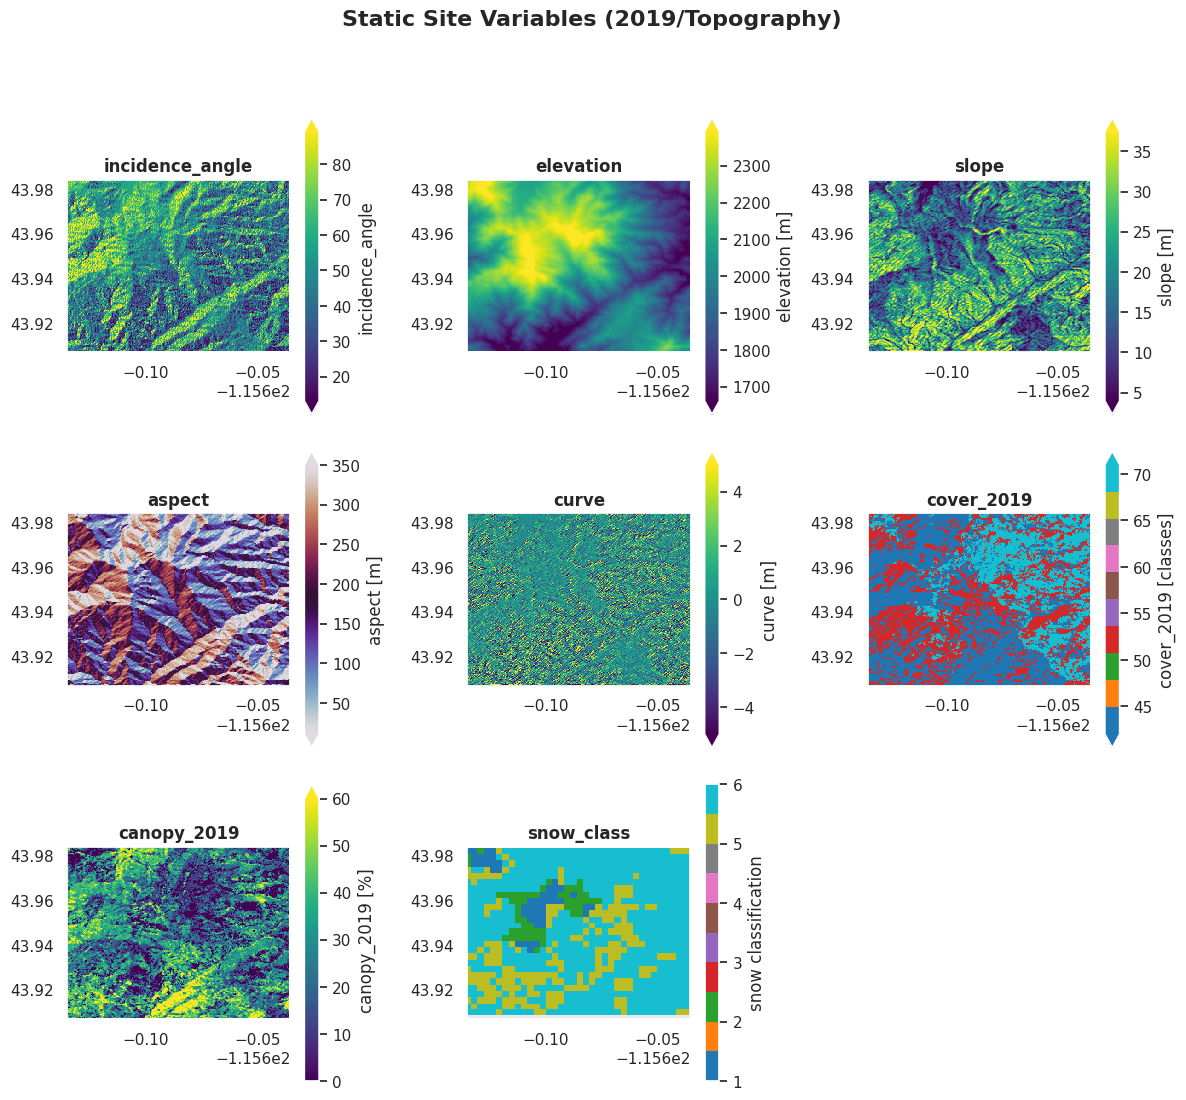

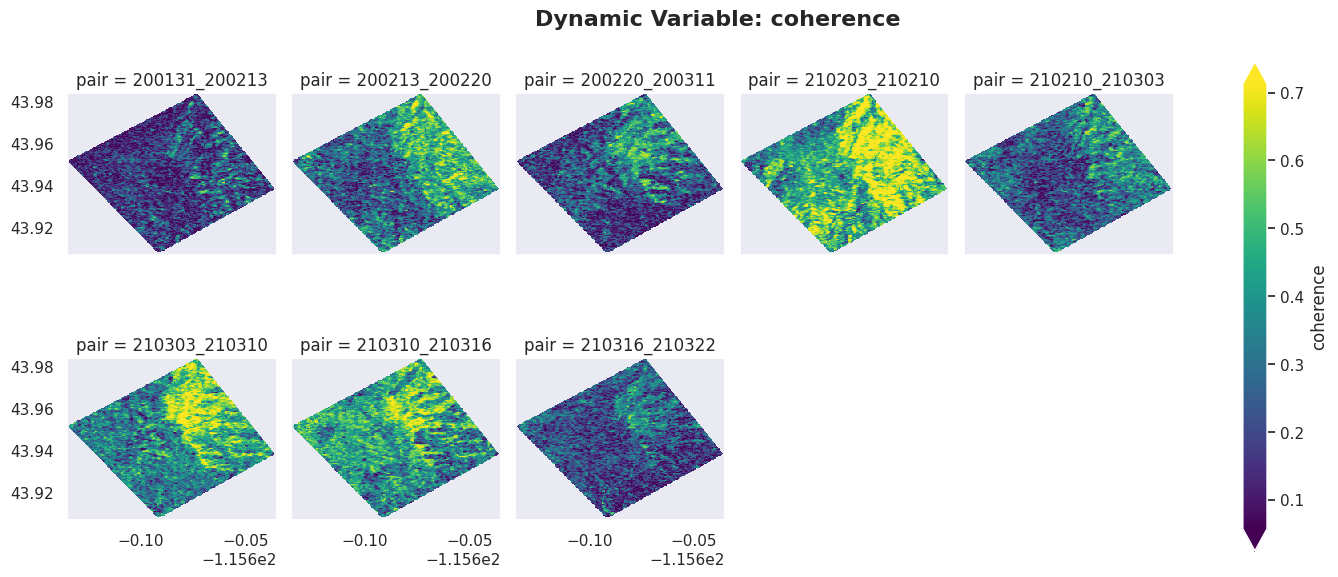

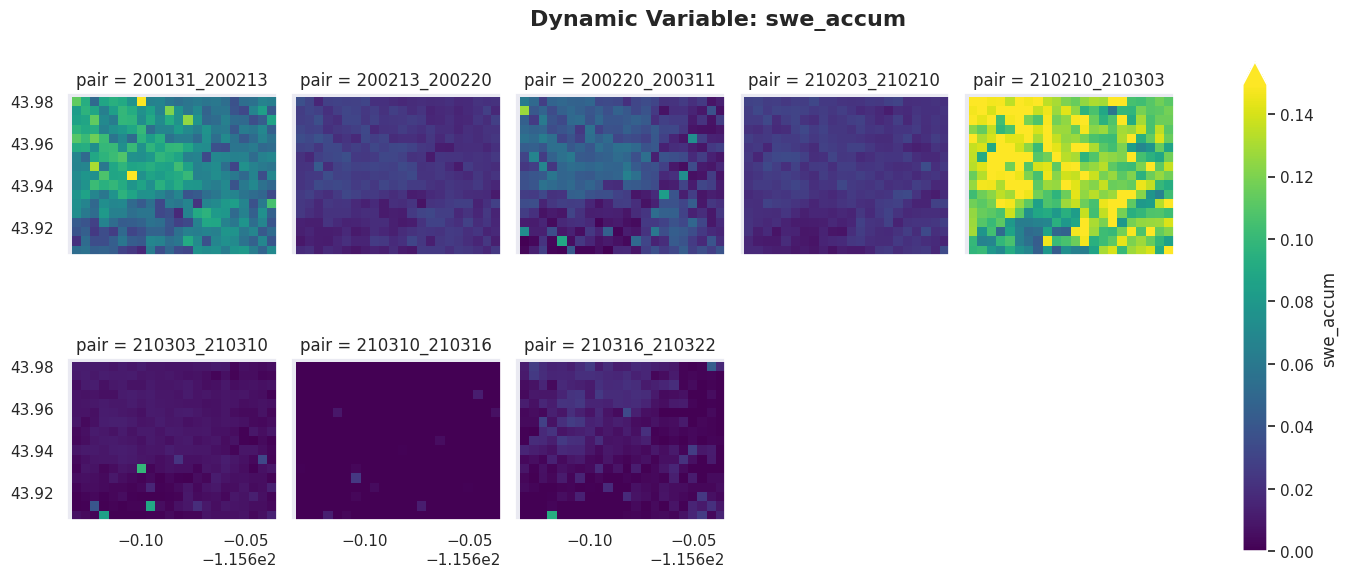

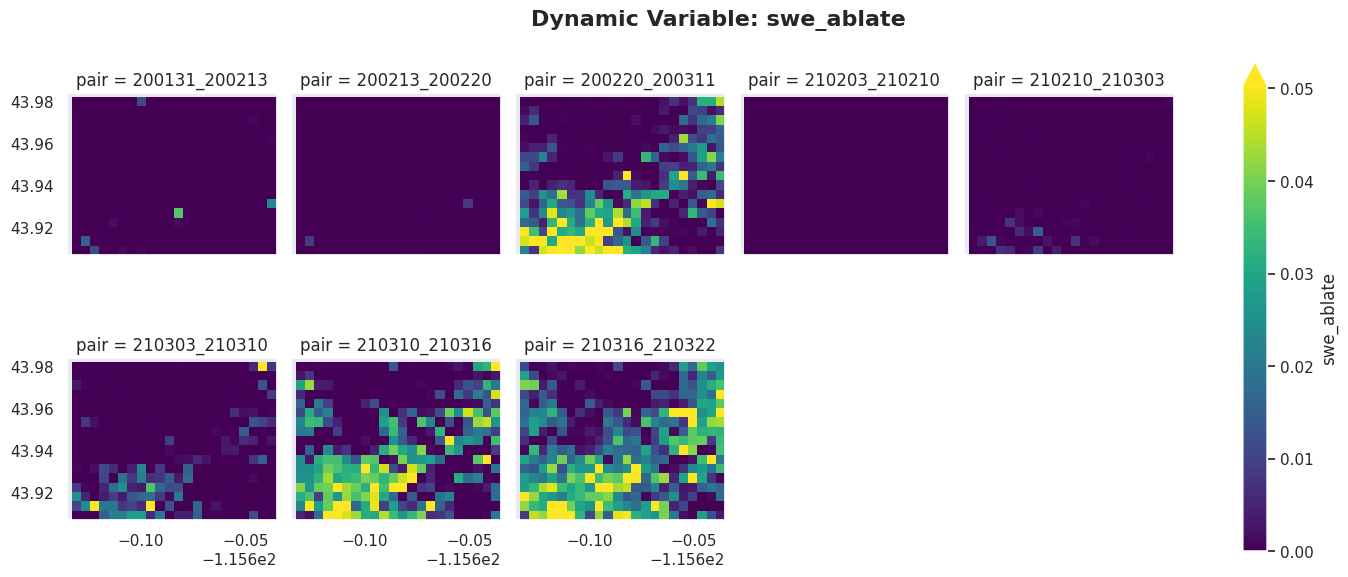

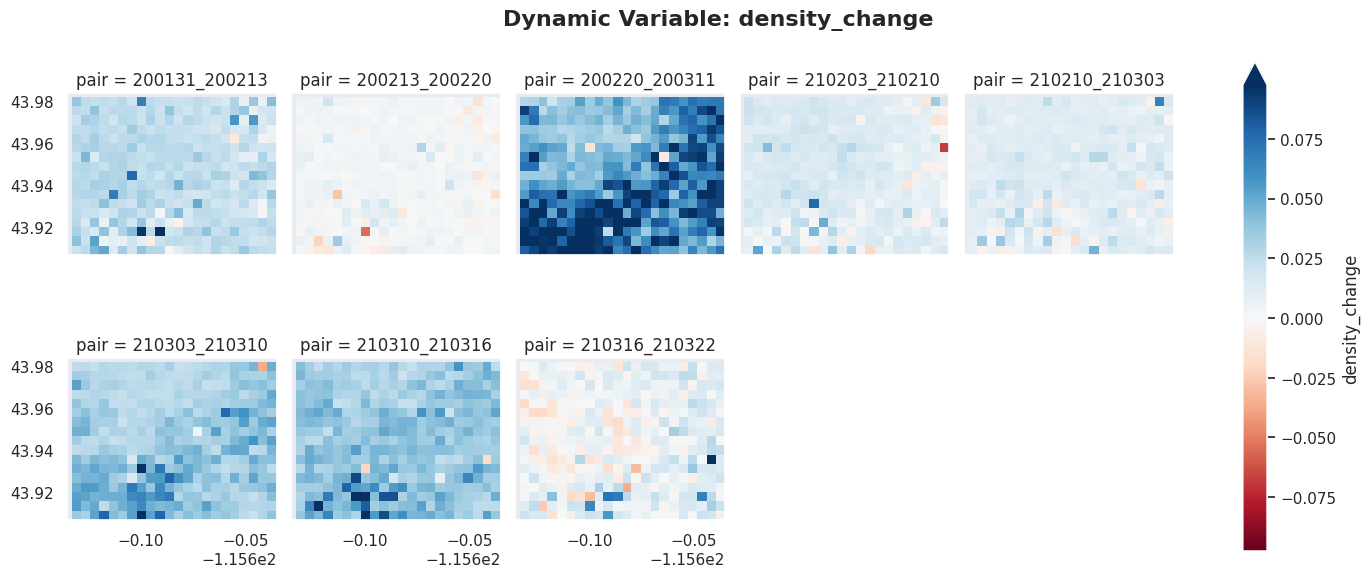

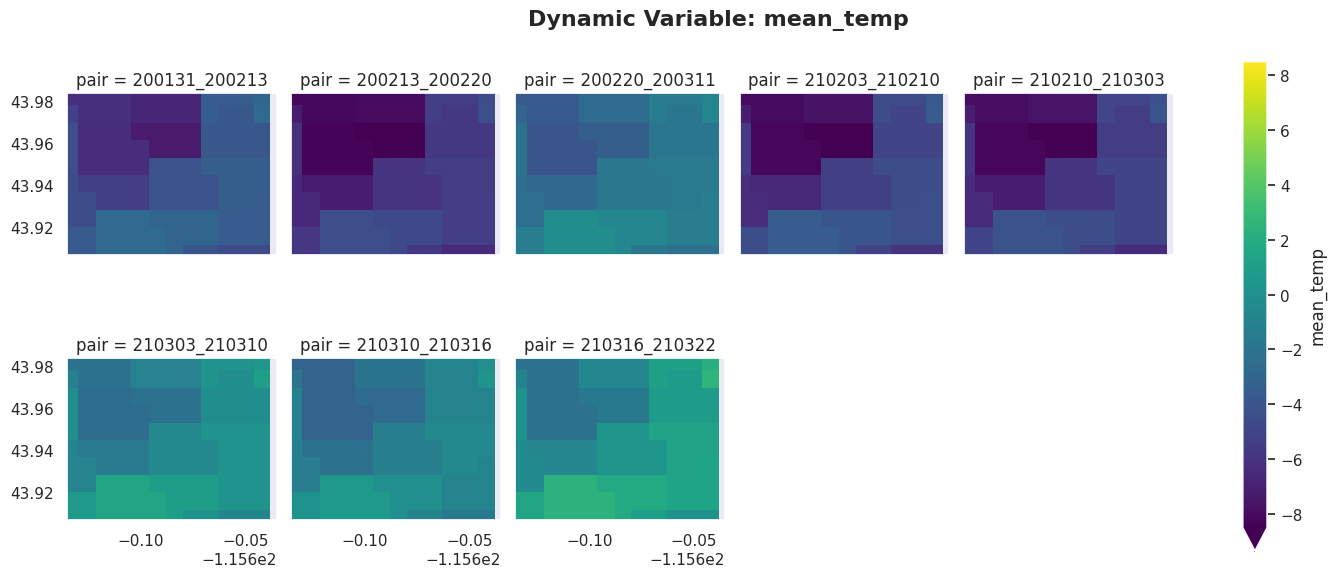

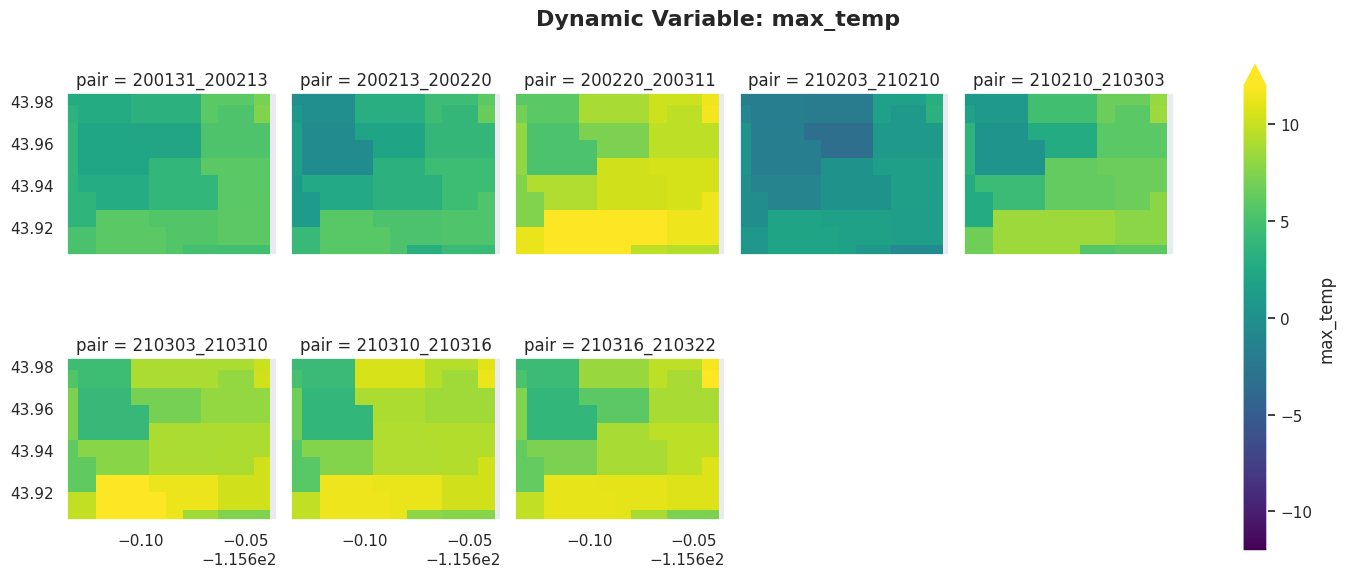

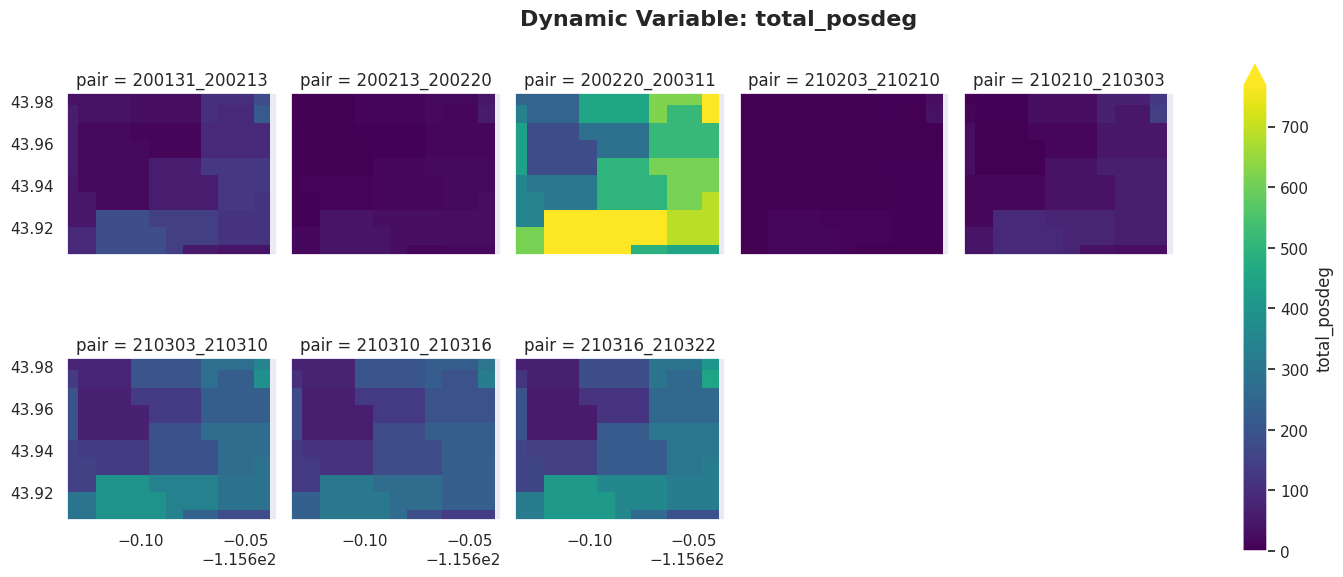

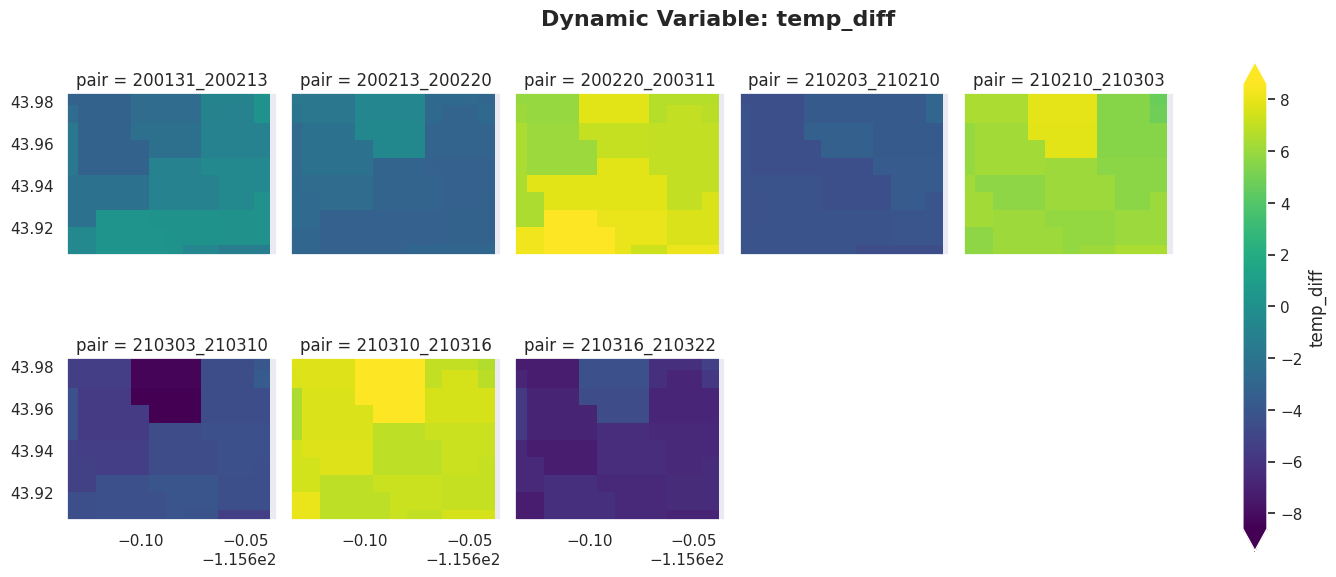

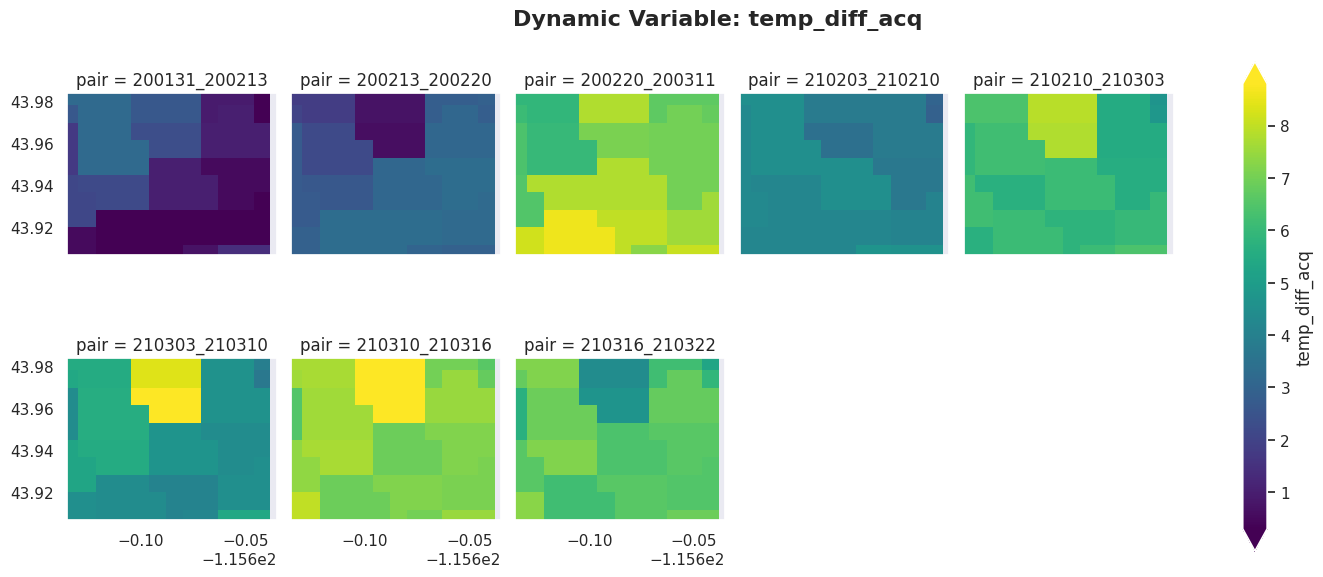

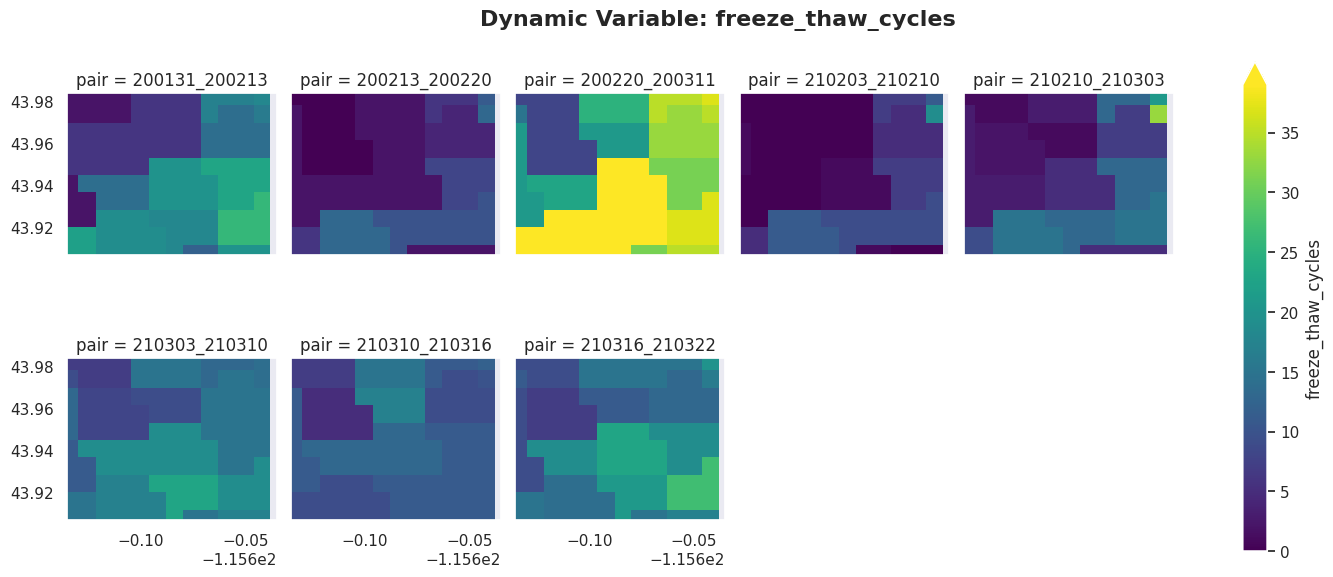

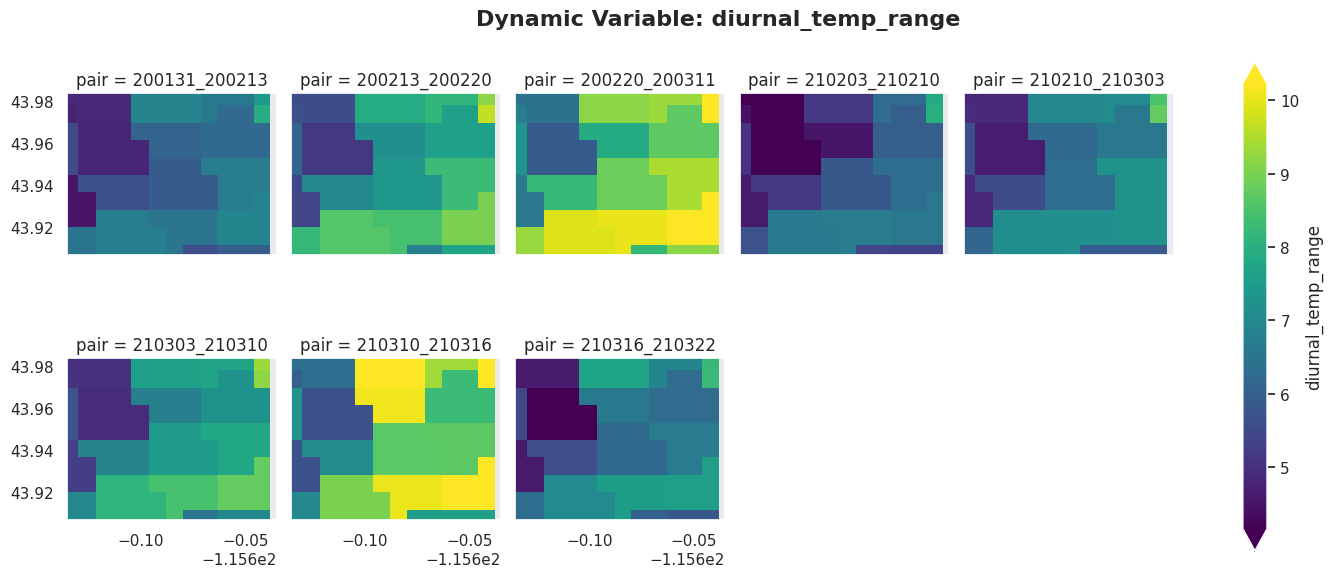

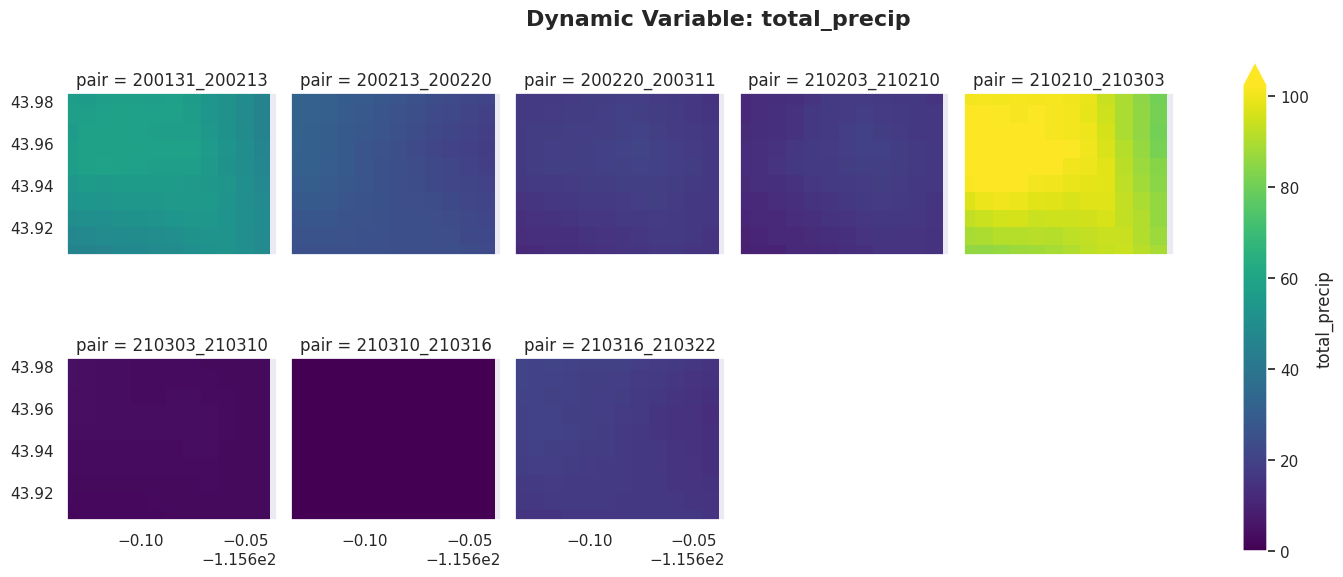

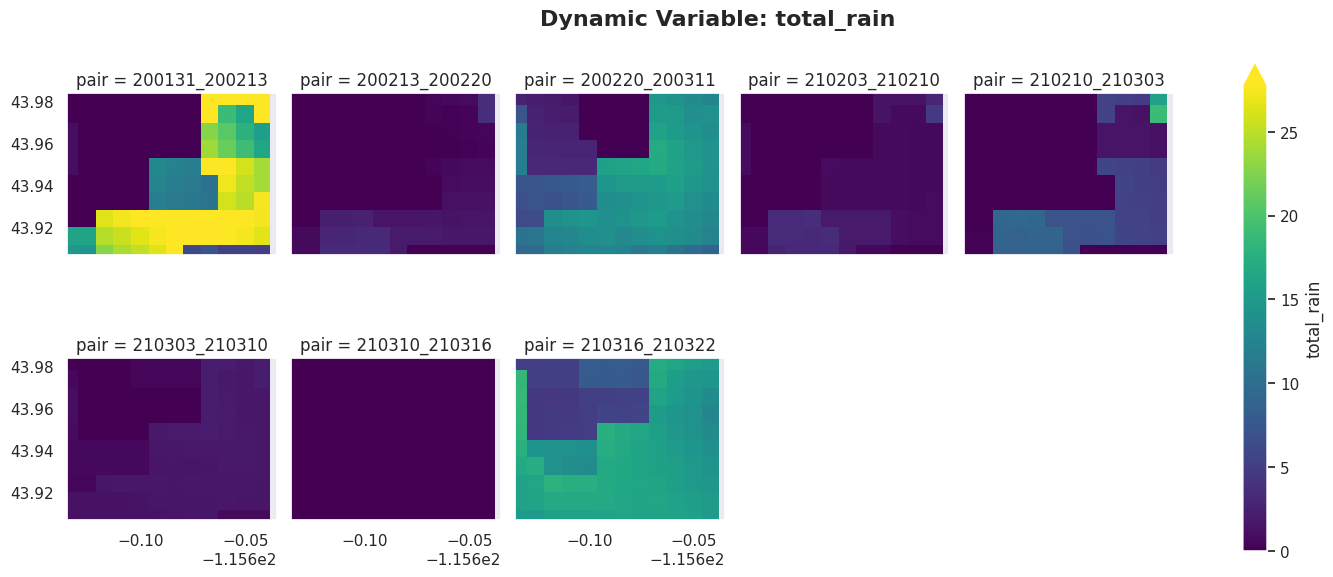

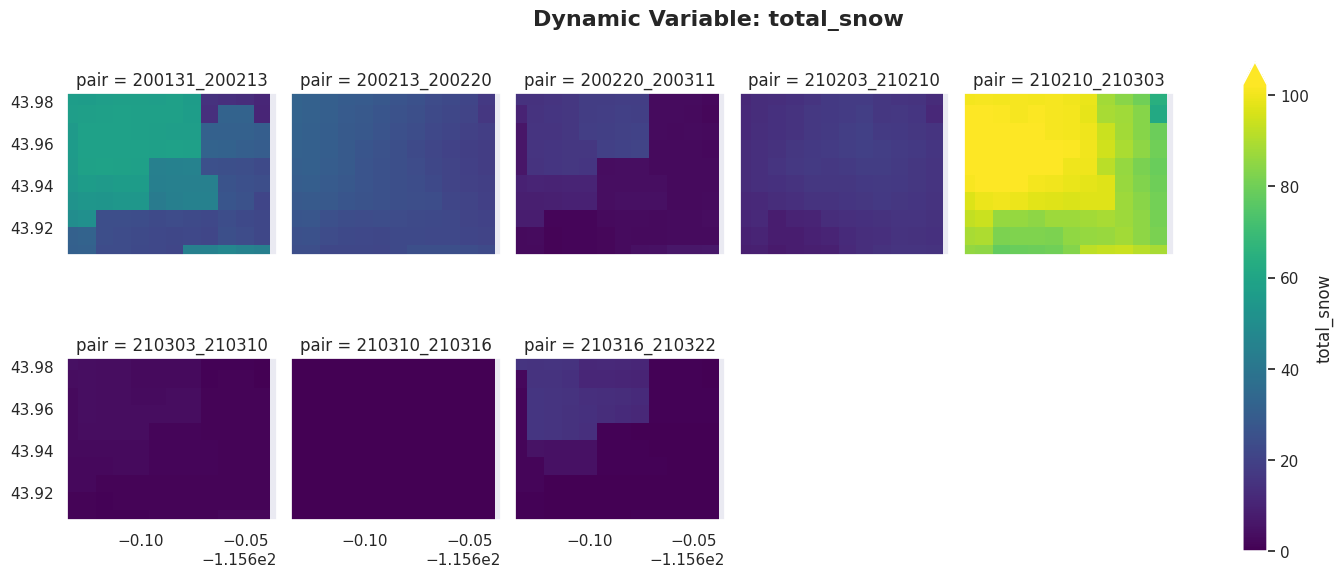

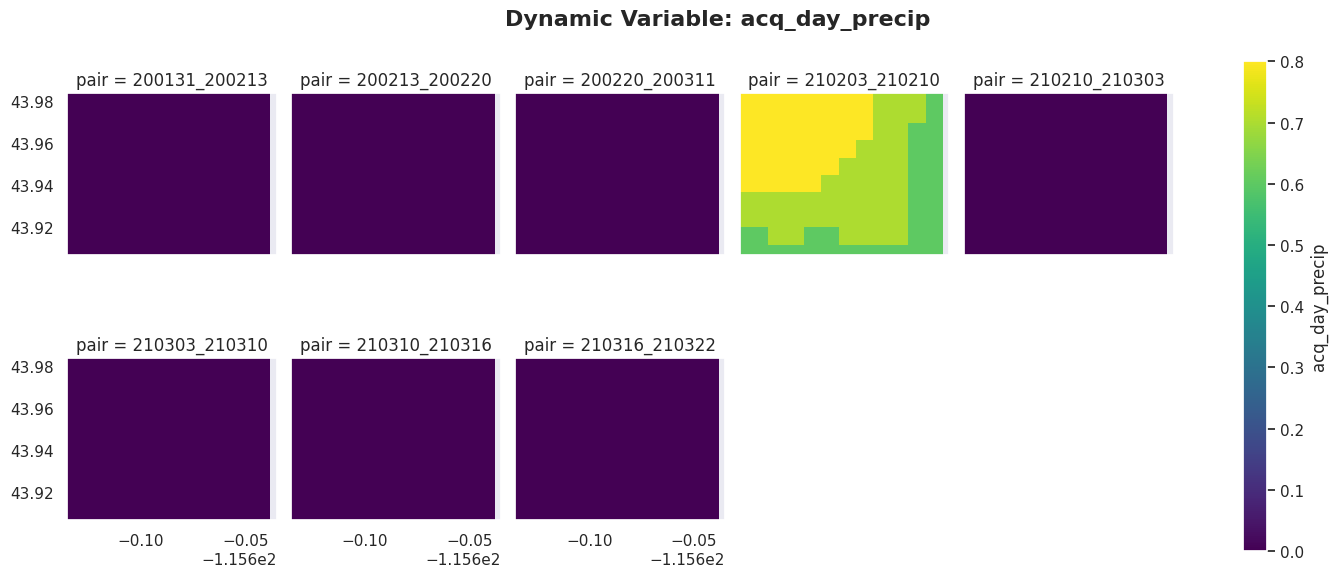

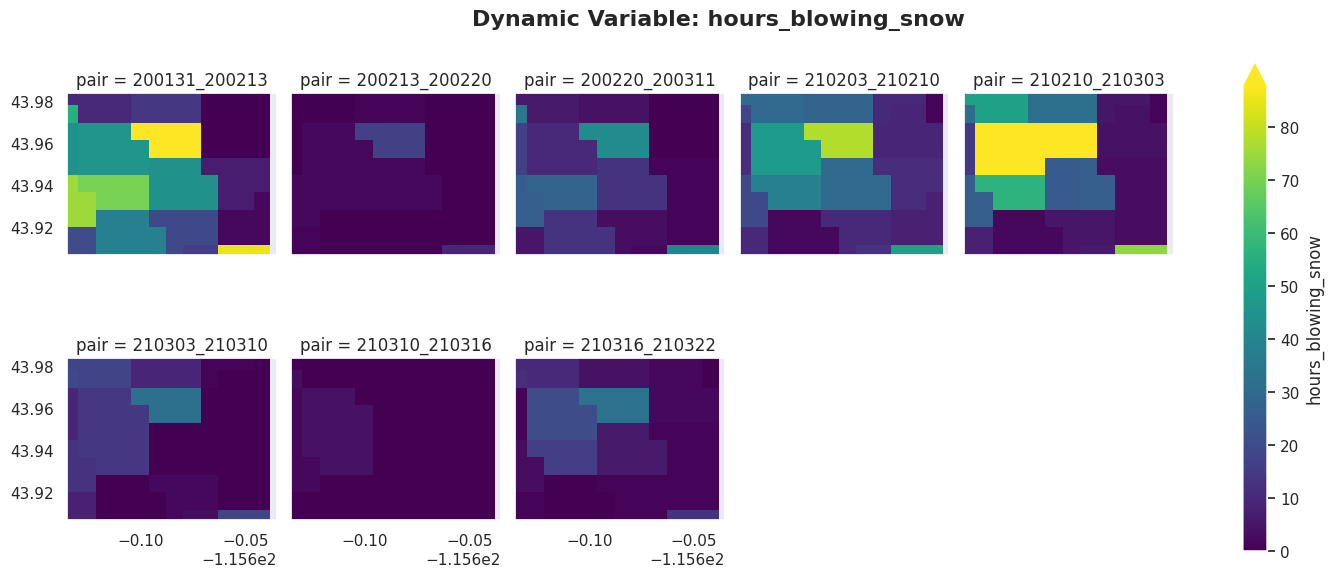

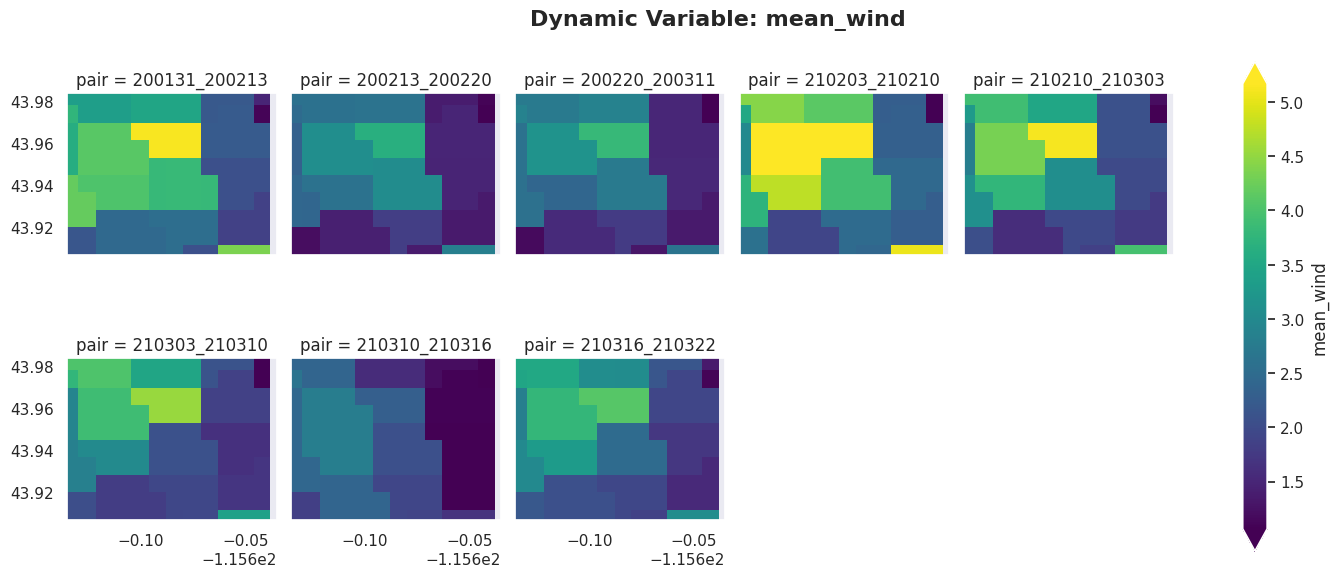

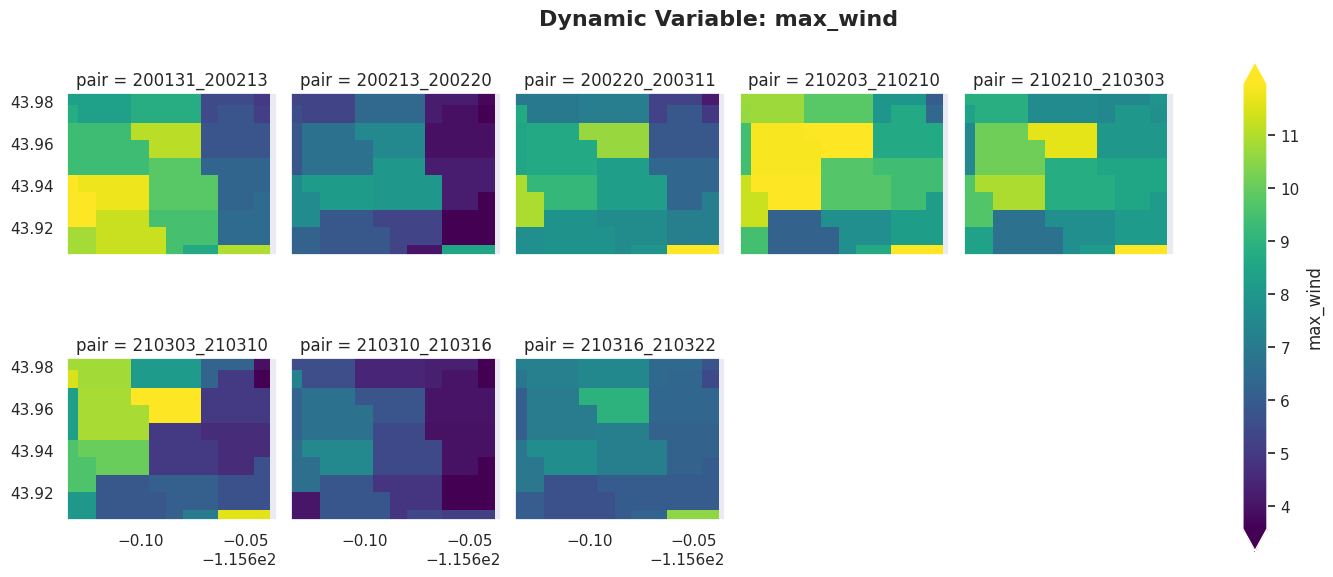

In [8]:
# plot the variables

# 1. Separate variables into two lists based on their dimensions
static_vars = [var for var in data.data_vars if 'pair' not in data[var].dims]
pair_vars = [var for var in data.data_vars if 'pair' in data[var].dims]

# ==========================================
# 2. PLOT STATIC VARIABLES (Single Dashboard)
# ==========================================
n_static = len(static_vars)
cols = 3
rows = int(np.ceil(n_static / cols))

# Create one figure for all static variables
fig_static, axes_static = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3.5))
axes_static = axes_static.flatten()

for i, var in enumerate(static_vars):
    ax = axes_static[i]
    
    if var in 'aspect' : cmap = 'twilight'  # cyclic colormap for aspect
    elif var in ['snow_class', 'cover_2019']: cmap = 'tab10'  # categorical colormap for classes
    else: cmap = 'viridis'  # standard colormap for other variables

    # robust=True drops top/bottom 2% of extreme values for a prettier color stretch
    data[var].plot(ax=ax, robust=True, cmap=cmap) 

    
    ax.set_title(var, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_aspect('equal') # Keeps pixels square since this is spatial data

# Hide any empty subplots if n_static doesn't divide perfectly by 3
for j in range(i + 1, len(axes_static)):
    axes_static[j].set_visible(False)

fig_static.suptitle('Static Site Variables (2019/Topography)', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()


# ==========================================
# 3. PLOT DYNAMIC VARIABLES (One Figure Each)
# ==========================================
for var in pair_vars:
    # Pick a diverging colormap for 'change' variables, standard for others
    cmap = 'RdBu' if 'change' in var else 'viridis'
    
    # Xarray automatically creates a multi-panel figure when you use col=
    # plot only nearest_dates
    fg = data[var].sel(pair=nearest_dates).plot(
        col='pair',
        col_wrap=5,  # 5 plots per row looks nice for 45 pairs
        figsize=(15, 3 * int(np.ceil(len(nearest_dates) / 5))),
        robust=True,
        cmap=cmap
    )

    # fg = data[var].plot(
    #     col='pair',
    #     col_wrap=5,  # 5 plots per row looks nice for 45 pairs
    #     figsize=(15, 3 * int(np.ceil(data.sizes['pair'] / 5))),
    #     robust=True,
    #     cmap=cmap
    # )
    
    # Add a main title for this specific variable's figure
    fg.fig.suptitle(f'Dynamic Variable: {var}', fontsize=16, fontweight='bold', y=1.02)
    
    # Clean up the individual axes
    for ax in fg.axs.flat:
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.set_aspect('equal')
        
    plt.show()